# Sensor Modality and Walkability Dimension Co-occurrence Analysis

In [1]:
import json
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"axes.labelsize": 14})
plt.rcParams.update({"xtick.labelsize": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

MATTE_COLORS = {
    "blue": "#4f9dc4",
    "red": "#e9785a",
    "teal": "#8ed165",
    "navy": "#3b3d3f",
    "gold": "#f2d156",
    "text": "#333333",
    "pink": "#d97eb8",
    "purple": "#9478d5",
    "grid": "#dddddd",
    "background": "#f7f7f7",
}

# 1. Load Dataset

In [2]:
df = pd.read_json("../data/06_4_dimensions_with_sensor_types.json")
df["macro_dimensions"] = df["macro_dimensions"].apply(lambda x: x if isinstance(x, list) else [])
df["macro_sensor_types"] = df["macro_sensor_types"].apply(lambda x: x if isinstance(x, list) else [])

print(f"Loaded {len(df)} articles")
print(f"Articles with at least one sensor category: {(df['macro_sensor_types'].str.len() > 0).sum()}")

Loaded 737 articles
Articles with at least one sensor category: 366


# 2. Sensing Modality Distribution

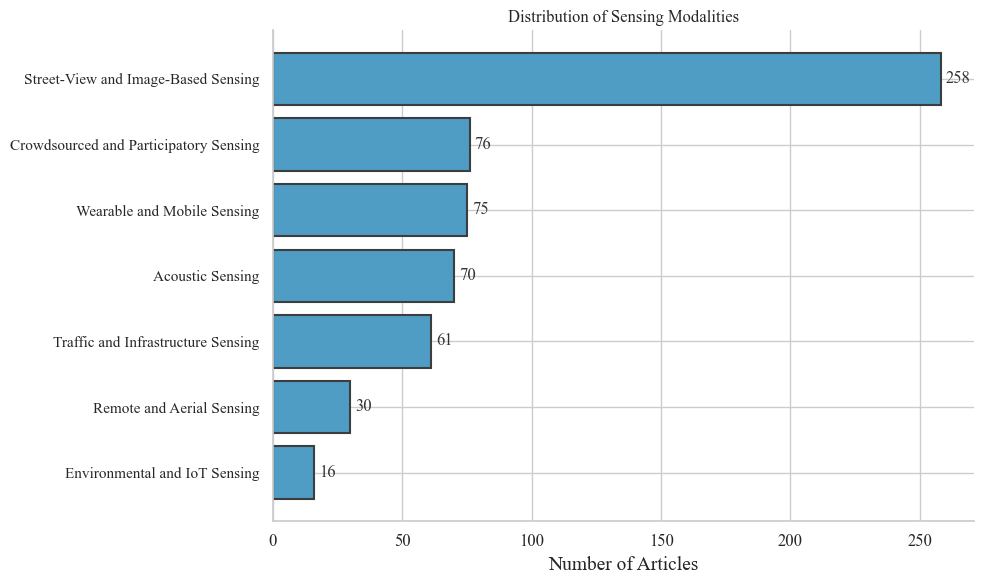

In [3]:
sensor_counts = Counter()
for categories in df["macro_sensor_types"]:
    sensor_counts.update(categories)

df_sensors = pd.DataFrame(sensor_counts.most_common(), columns=["Sensor Category", "Count"])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_sensors["Sensor Category"][::-1], df_sensors["Count"][::-1],
                color=MATTE_COLORS["blue"], edgecolor=MATTE_COLORS["navy"], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            va="center", color=MATTE_COLORS["text"])
ax.set_xlabel("Number of Articles")
ax.set_title("Distribution of Sensing Modalities")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 3. Walkability Dimension Distribution

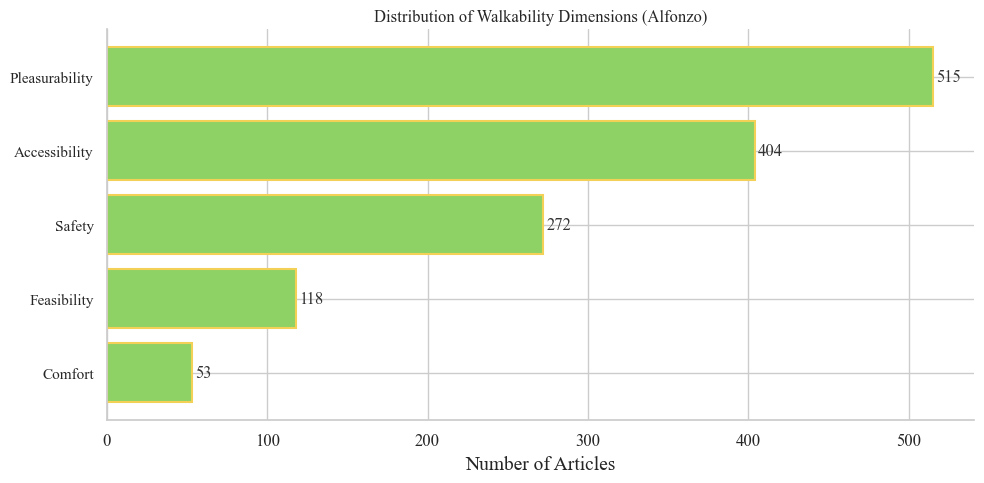

In [4]:
dimension_counts = Counter()
for dimensions in df["macro_dimensions"]:
    dimension_counts.update(dimensions)

df_dimensions = pd.DataFrame(dimension_counts.most_common(), columns=["Dimension", "Count"])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_dimensions["Dimension"][::-1], df_dimensions["Count"][::-1],
                color=MATTE_COLORS["teal"], edgecolor=MATTE_COLORS["gold"], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            va="center", color=MATTE_COLORS["text"])
ax.set_xlabel("Number of Articles")
ax.set_title("Distribution of Walkability Dimensions (Alfonzo)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Sensor x Dimension Cross-Tabulation

In [5]:
pairs = []
for _, row in df.iterrows():
    for sensor in row["macro_sensor_types"]:
        for dimension in row["macro_dimensions"]:
            pairs.append({"sensor": sensor, "dimension": dimension})

pairs_df = pd.DataFrame(pairs)
crosstab_counts = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"])
crosstab_row_pct = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"], normalize="index") * 100

n_with_both = (df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)
print(f"Articles contributing to the cross-tabulation (sensor and dimension both assigned): {n_with_both.sum()}")

crosstab_counts

Articles contributing to the cross-tabulation (sensor and dimension both assigned): 366


dimension,Accessibility,Comfort,Feasibility,Pleasurability,Safety
sensor,,,,,
Acoustic Sensing,28,11,2,52,22
Crowdsourced and Participatory Sensing,37,5,6,52,36
Environmental and IoT Sensing,7,8,4,7,7
Remote and Aerial Sensing,14,3,2,26,8
Street-View and Image-Based Sensing,136,13,23,202,114
Traffic and Infrastructure Sensing,36,4,10,36,38
Wearable and Mobile Sensing,34,4,8,63,14


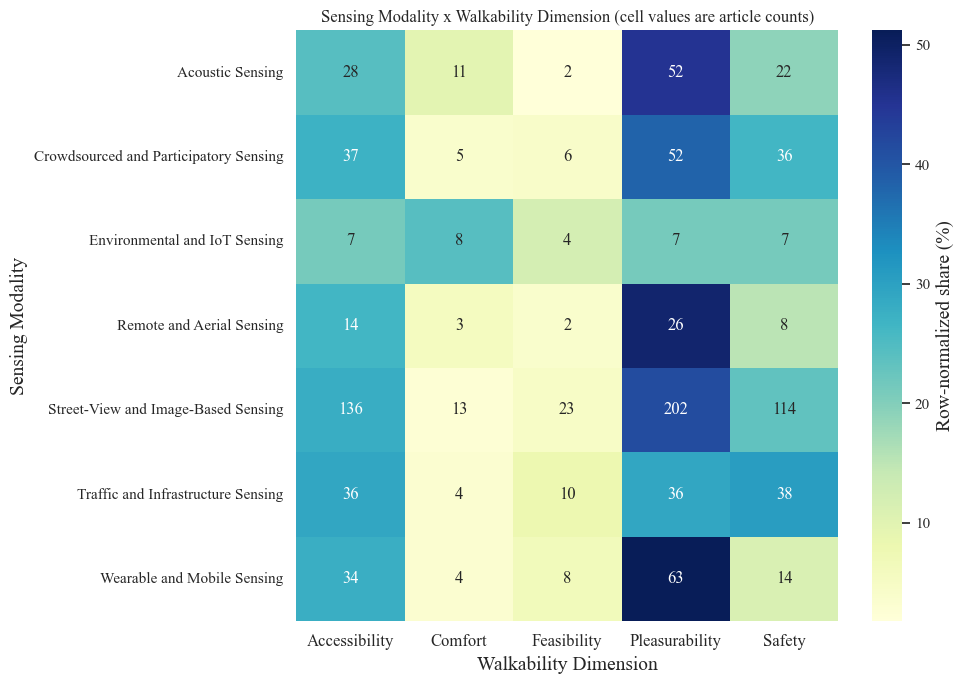

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(crosstab_row_pct, annot=crosstab_counts, fmt="d", cmap="YlGnBu",
            cbar_kws={"label": "Row-normalized share (%)"}, ax=ax)
ax.set_title("Sensing Modality x Walkability Dimension (cell values are article counts)")
ax.set_xlabel("Walkability Dimension")
ax.set_ylabel("Sensing Modality")
plt.tight_layout()
plt.show()

# 5. Statistical Association: Chi-Square Test and Standardized Residuals

Chi-square statistic: 75.80
Degrees of freedom: 24
p-value: 2.8e-07


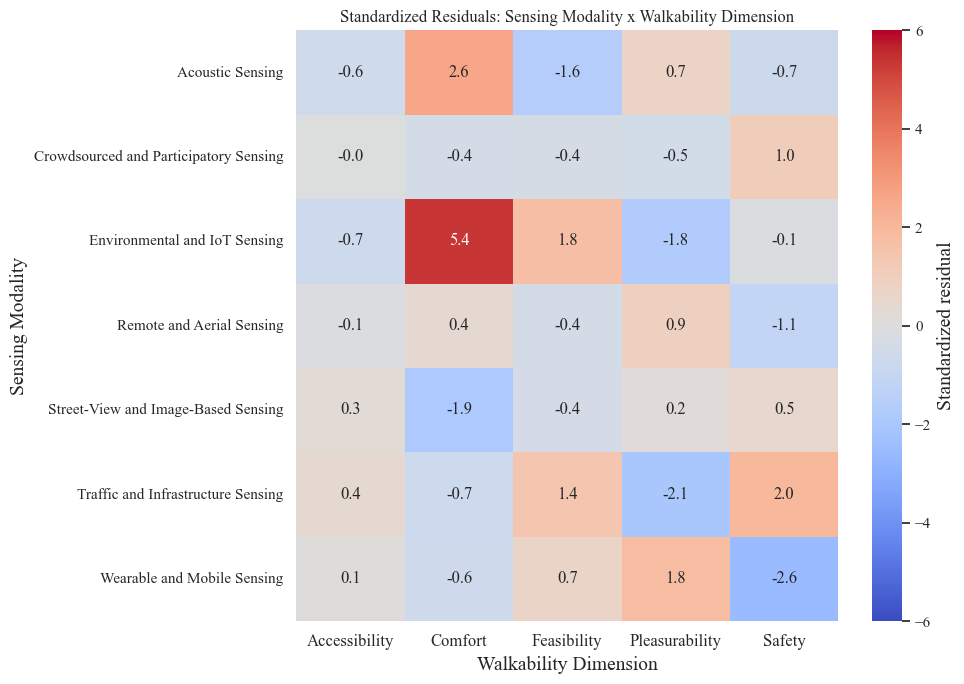


Cells with |standardized residual| > 2 (association stronger than expected under independence):
  - Acoustic Sensing x Comfort: 2.58 (over-represented)
  - Environmental and IoT Sensing x Comfort: 5.37 (over-represented)
  - Traffic and Infrastructure Sensing x Pleasurability: -2.06 (under-represented)
  - Wearable and Mobile Sensing x Safety: -2.56 (under-represented)


In [7]:
chi2, p_value, dof, expected = chi2_contingency(crosstab_counts)
expected_df = pd.DataFrame(expected, index=crosstab_counts.index, columns=crosstab_counts.columns)
standardized_residuals = (crosstab_counts - expected_df) / np.sqrt(expected_df)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4g}")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(standardized_residuals, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            vmin=-6, vmax=6, cbar_kws={"label": "Standardized residual"}, ax=ax)
ax.set_title("Standardized Residuals: Sensing Modality x Walkability Dimension")
ax.set_xlabel("Walkability Dimension")
ax.set_ylabel("Sensing Modality")
plt.tight_layout()
plt.show()

print("\nCells with |standardized residual| > 2 (association stronger than expected under independence):")
for sensor in standardized_residuals.index:
    for dimension in standardized_residuals.columns:
        value = standardized_residuals.loc[sensor, dimension]
        if abs(value) > 2:
            direction = "over-represented" if value > 0 else "under-represented"
            print(f"  - {sensor} x {dimension}: {value:.2f} ({direction})")

# 6. Article-Level Archetypes: Hierarchical Clustering

In [8]:
archetype_df = df[(df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)].copy()
archetype_df = archetype_df.reset_index(drop=True)

sensor_dummies = pd.get_dummies(archetype_df["macro_sensor_types"].explode()).groupby(level=0).max()
dimension_dummies = pd.get_dummies(archetype_df["macro_dimensions"].explode()).groupby(level=0).max()
feature_matrix = pd.concat([sensor_dummies, dimension_dummies], axis=1).fillna(0).astype(int)

print(f"Articles included in archetype analysis: {len(feature_matrix)}")
print(f"Feature dimensions (sensor categories + walkability dimensions): {feature_matrix.shape[1]}")

distance_matrix = squareform(pdist(feature_matrix.values, metric="jaccard"))
condensed_distance = pdist(feature_matrix.values, metric="jaccard")
linkage_matrix = linkage(condensed_distance, method="average")

Articles included in archetype analysis: 366
Feature dimensions (sensor categories + walkability dimensions): 12


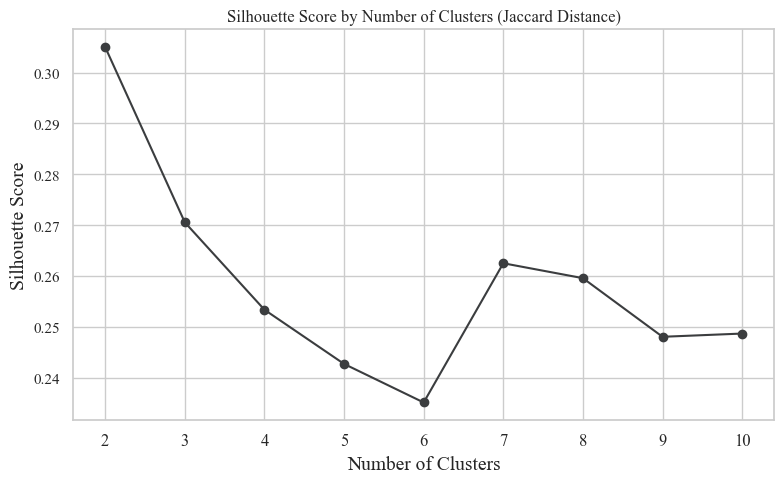

Selected number of clusters: 2 (silhouette score: 0.305)


In [9]:
silhouette_scores = {}
for k in range(2, 11):
    cluster_labels = fcluster(linkage_matrix, t=k, criterion="maxclust")
    if len(set(cluster_labels)) > 1:
        silhouette_scores[k] = silhouette_score(distance_matrix, cluster_labels, metric="precomputed")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), "o-", color=MATTE_COLORS["navy"])
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters (Jaccard Distance)")
plt.tight_layout()
plt.show()

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Selected number of clusters: {optimal_k} (silhouette score: {silhouette_scores[optimal_k]:.3f})")

cluster_labels = fcluster(linkage_matrix, t=optimal_k, criterion="maxclust") - 1
archetype_df["cluster"] = cluster_labels

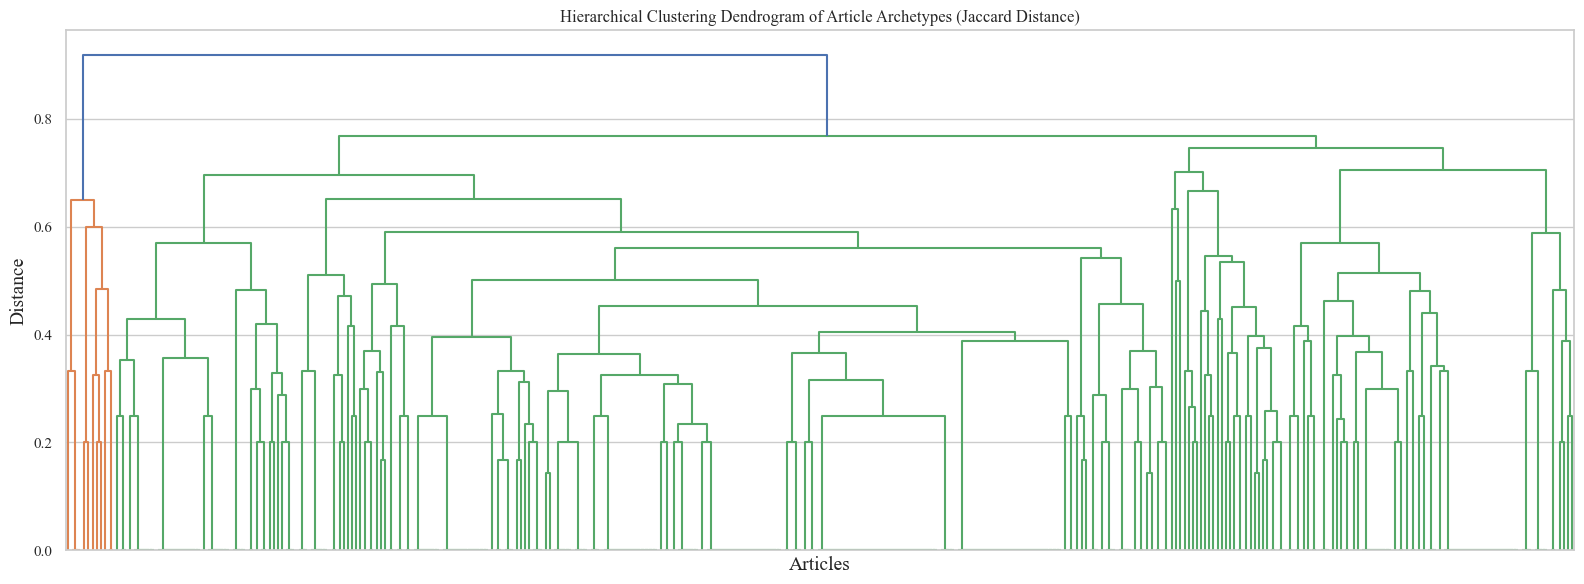

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=linkage_matrix[-(optimal_k - 1), 2])
ax.set_title("Hierarchical Clustering Dendrogram of Article Archetypes (Jaccard Distance)")
ax.set_xlabel("Articles")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

# 7. MDS Projection of Article Archetypes

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


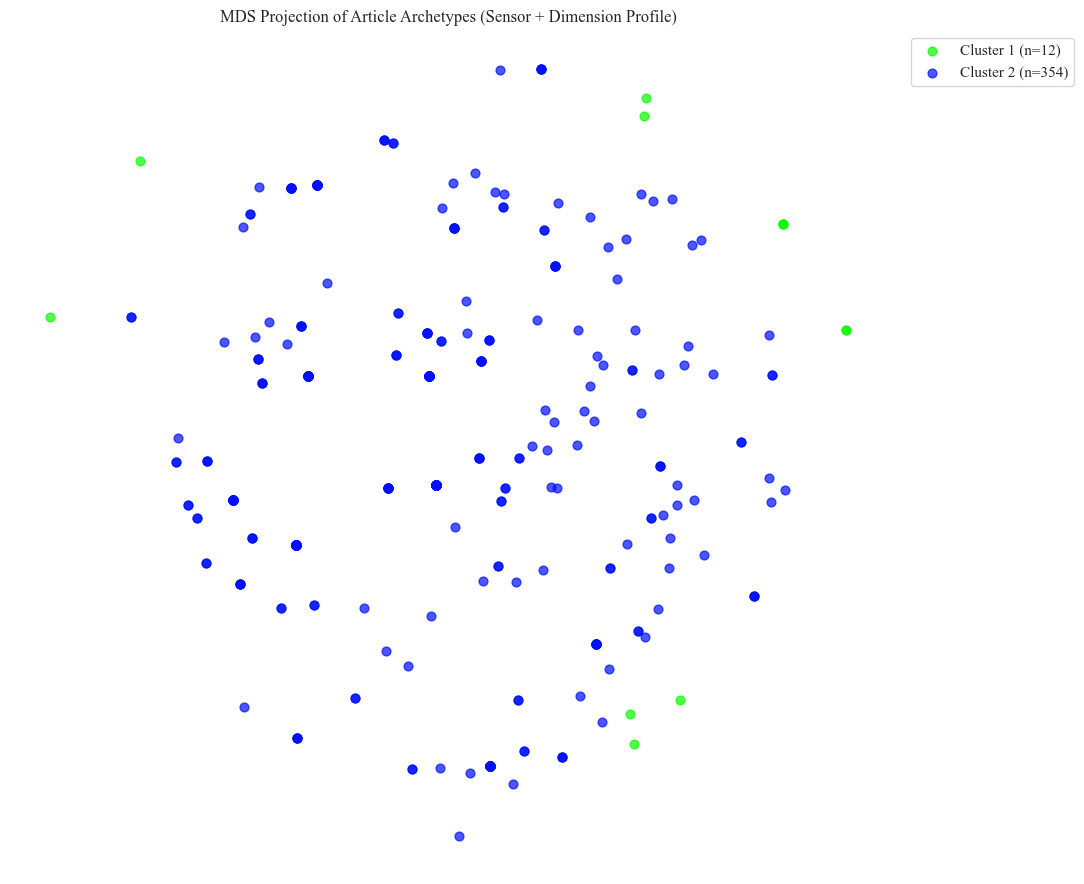

In [11]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
positions = mds.fit_transform(distance_matrix)

palette = sns.color_palette("hsv", optimal_k)

fig, ax = plt.subplots(figsize=(11, 9))
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(positions[mask, 0], positions[mask, 1], s=40, alpha=0.7,
               color=palette[cluster_id], label=f"Cluster {cluster_id + 1} (n={mask.sum()})")

ax.set_title("MDS Projection of Article Archetypes (Sensor + Dimension Profile)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axis("off")
plt.tight_layout()
plt.show()

# 8. Cluster Composition Summary

In [12]:
summary_rows = []
for cluster_id in range(optimal_k):
    cluster_data = archetype_df[archetype_df["cluster"] == cluster_id]

    sensor_counts_cluster = Counter()
    for categories in cluster_data["macro_sensor_types"]:
        sensor_counts_cluster.update(categories)

    dimension_counts_cluster = Counter()
    for dimensions in cluster_data["macro_dimensions"]:
        dimension_counts_cluster.update(dimensions)

    top_sensor = sensor_counts_cluster.most_common(1)[0][0] if sensor_counts_cluster else "-"
    top_dimension = dimension_counts_cluster.most_common(1)[0][0] if dimension_counts_cluster else "-"

    summary_rows.append({
        "Cluster": cluster_id + 1,
        "Size": len(cluster_data),
        "Dominant Sensor": top_sensor,
        "Dominant Dimension": top_dimension,
        "Top 3 Sensors": ", ".join(s for s, _ in sensor_counts_cluster.most_common(3)),
        "Top 3 Dimensions": ", ".join(d for d, _ in dimension_counts_cluster.most_common(3)),
    })

cluster_summary = pd.DataFrame(summary_rows).set_index("Cluster")
cluster_summary

,Size,Dominant Sensor,Dominant Dimension,Top 3 Sensors,Top 3 Dimensions
Cluster,,,,,
1,12,Environmental and IoT Sensing,Comfort,"Environmental and IoT Sensing, Acoustic Sensing, Traffic and Infrastructure Sensing","Comfort, Pleasurability, Safety"
2,354,Street-View and Image-Based Sensing,Pleasurability,"Street-View and Image-Based Sensing, Crowdsourced and Participatory Sensing, Wearable and Mobile...","Pleasurability, Accessibility, Safety"
